# Algorithm 3 — SMC weighted flow maps on the FLUX.1-dev flow map

Sampling $q_\lambda(x) \propto p(x)\exp(\lambda f(x))$ with $f$ = **normalized squared global IEM**, in a
**single forward pass** over a two-timestep flow map — no tempering ladder, no rejuvenation.

**Why.** `adaptive_tempering_smc.py` + `PCNKernel` does not finish at FLUX scale: jobs 695271/697271 burned
~14 h and reached $\beta = 0.5422$ ($m_{\text{eff}}$ 1.63 of 3), with pCN acceptance collapsing
0.75 → 0.62 → 0.38 → 0.12. Every tempering level costs a full ladder of rejuvenation sweeps, and the ladder
never ends. Algorithm 3 replaces it with $N$ steps from noise to data. The question this notebook answers:
**does one ~3 h forward pass reach a tilt strength the pCN ladder could not reach in 14 h?**

**The model.** `gabeguofanclub/flux-1-dev-flowmap-lsd` — a rank-64 LoRA over the FLUX.1-dev transformer plus
a second timestep embedder, giving a velocity $u_\theta(x; t \to t_{to})$ conditioned on a *pair* of times.
Two operations, and they are not interchangeable:

$$\text{map}(x, t, 1) = x - \sigma_{t}u_\theta(x; t \to 1) \quad\text{(ODE endpoint, a sample)} \qquad
  \text{denoise}(x, t) = x - \sigma_{t}u_\theta(x; t \to t) \quad\text{(Tweedie mean, the score model)}$$

`denoise` is **not** `map(x, t, t)` — $X_{t,t}$ is the identity, which multiplies the velocity away. Getting
this wrong fails silently, giving the score of $N(0, \sigma_{t}^{2})$.

**This notebook owns everything that defines $p$** — the checkpoint, the prompt (`"A dog"`), the guidance
scale, the encoded embeddings — and hands only closures to the library, exactly as
`flux_dev_strong_tilt_sweep_2_1.ipynb` does. The library never sees a prompt.

**Phases** (`STOP_AFTER` selects how far to go):

| phase | what | cost |
|---|---|---|
| 1 `health` | model wiring + gate: load validation, latent std, `denoise` $\neq$ `map` | ~20 min |
| 3 `refs` | $R{=}64$ references from an **untilted** run, persisted; frozen reward; $\lambda_s$ on a **held-out** batch | ~45 min |
| 4 `run` | the tilted run, $\lambda = m\lambda_s$, per-step checkpointing | ~3 h per $m$ |
| 5 | decoded grid, diagnostics, Takeaways | ~10 min |

Phase 2 (the sampler and its 43 tests) is CPU-only and lives in `creativity_measure/flowmap_smc.py` /
`tests/test_flowmap_smc.py`; it must be green before any of this runs.

In [1]:
import json
import math
import os
import sys
import time

import matplotlib.pyplot as plt
import torch

T_START = time.time()

REPO = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if not os.path.isdir(os.path.join(REPO, "creativity_measure")):
    REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO not in sys.path:
    sys.path.insert(0, REPO)
RUN_DIR = os.path.join(REPO, "notebooks", "flowmap_smc_flux")
os.makedirs(RUN_DIR, exist_ok=True)

# --- what to run ----------------------------------------------------------------------------------
# The phases are cumulative and each caches to disk, so a later job loads what an earlier one built.
# STOP_AFTER lets one notebook + one .slurm serve the whole execution order: submit with "health"
# first (the gate), then "refs", then "run".
STOP_AFTER = os.environ.get("STOP_AFTER", "run")          # health | refs | run
assert STOP_AFTER in ("health", "refs", "run"), STOP_AFTER
DO_REFS = STOP_AFTER in ("refs", "run")
DO_RUN = STOP_AFTER == "run"
RUN_TAG = os.environ.get("RUN_TAG", "a3_1")

# --- wall clock -----------------------------------------------------------------------------------
# The SMC is one long library call, so it cannot be interrupted from outside; the `on_step` callback
# checks DEADLINE after every step instead. RESERVE_H is held back for decoding and rendering.
# Under Slurm, SLURM_JOB_END_TIME is the job's real end, so the deadline tracks --time automatically.
WALL_BUDGET_H = float(os.environ.get("WALL_BUDGET_H", 6.0))   # keep in sync with --time in the .slurm
RESERVE_H = 0.75                                              # VAE decoding, rendering, writing out
try:
    _end = float(os.environ["SLURM_JOB_END_TIME"])
except (KeyError, ValueError):
    _end = None
if _end and _end > T_START:
    DEADLINE, WALL_BUDGET_H, _src = _end - RESERVE_H * 3600, (_end - T_START) / 3600, "SLURM"
else:
    DEADLINE, _src = T_START + (WALL_BUDGET_H - RESERVE_H) * 3600, "constant"

from creativity_measure import set_default_dtype

set_default_dtype(torch.float32)          # FLUX runs bf16; everything the SMC touches is fp32
torch.manual_seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16                    # transformer compute dtype; particles stay fp32

from huggingface_hub import auth_check

auth_check("black-forest-labs/FLUX.1-dev")
print(f"device {DEVICE} ({DTYPE})   budget {WALL_BUDGET_H:.2f} h via {_src}")
print(f"deadline {time.strftime('%H:%M:%S', time.localtime(DEADLINE))}")
print(f"STOP_AFTER={STOP_AFTER!r}  run tag {RUN_TAG!r}   FLUX.1-dev access: OK")

/home/dcor/arielzoizner/miniconda3/envs/creativity-measure/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device cuda (torch.bfloat16)   budget 0.97 h via SLURM
deadline 23:13:55
STOP_AFTER='health'  run tag 'a3_1'   FLUX.1-dev access: OK


In [2]:
from diffusers import FluxPipeline

MODEL_ID = "black-forest-labs/FLUX.1-dev"
PROMPT = "A dog"

# GUIDANCE = 1.0 for the flow map (the pCN sweeps used 1.5 / 3.5 on base FLUX). Together with PROMPT
# and the checkpoint this IS p, so it is fixed here and never exposed to the library.
GUIDANCE = 1.0

IMG = 512
C, H, W = 16, IMG // 8, IMG // 8       # VAE downsamples 8x; FLUX latents have 16 channels
LATENT_DIM = C * H * W                 # 65536 -- the geometry the FLUX reward machinery is tuned for

pipe = FluxPipeline.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)
with torch.no_grad():
    prompt_embeds, pooled_prompt_embeds, text_ids = pipe.encode_prompt(
        prompt=PROMPT, prompt_2=None, device=DEVICE, max_sequence_length=512
    )
# Free both text encoders (~9.5 GB, T5 dominates): the embeddings above are all we need.
pipe.text_encoder = pipe.text_encoder_2 = pipe.tokenizer = pipe.tokenizer_2 = None
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
transformer, vae = pipe.transformer.eval(), pipe.vae.eval()
VAE_SF, VAE_SHIFT = vae.config.scaling_factor, vae.config.shift_factor
print(f"loaded {MODEL_ID}  prompt={PROMPT!r}  guidance={GUIDANCE}  "
      f"guidance_embeds={transformer.config.guidance_embeds}")
print(f"latents ({C}, {H}, {W}) = d {LATENT_DIM}  vae scaling={VAE_SF} shift={VAE_SHIFT}")


def decode(flat: torch.Tensor, chunk: int = 2) -> torch.Tensor:
    """Flat FLUX latents (B, d) -> images (B, 3, 512, 512) in [0, 1].

    Chunked because the VAE decoder, not the transformer, is the memory spike.
    """
    outs = []
    for i in range(0, flat.shape[0], chunk):
        lat = flat[i : i + chunk].reshape(-1, C, H, W).to(DEVICE, DTYPE) / VAE_SF + VAE_SHIFT
        with torch.no_grad():
            img = vae.decode(lat).sample
        outs.append(pipe.image_processor.postprocess(img.float(), output_type="pt").cpu())
    return torch.cat(outs)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading pipeline components...:  14%|█▍        | 1/7 [00:00<00:04,  1.33it/s]

Loading pipeline components...:  29%|██▊       | 2/7 [00:01<00:03,  1.61it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Loading checkpoint shards: 100%|██████████| 3/3 [00:11<00:00,  3.58s/it]

Loading checkpoint shards: 100%|██████████| 3/3 [00:11<00:00,  3.96s/it]


Loading pipeline components...: 100%|██████████| 7/7 [00:19<00:00,  4.45s/it]

Loading pipeline components...: 100%|██████████| 7/7 [00:19<00:00,  2.84s/it]

loaded black-forest-labs/FLUX.1-dev  prompt='A dog'  guidance=1.0  guidance_embeds=True
latents (16, 64, 64) = d 65536  vae scaling=0.3611 shift=0.1159


In [3]:
from creativity_measure import LinearSchedule, ddpm_step, flow_map_step
from creativity_measure.distances.edm_adapter import chunked_denoiser, edm_score_fn
from creativity_measure.generators.flux_flowmap import (
    FluxFlowMap, flow_map_denoiser, load_flow_map_weights,
)

# --- denoiser batch cap ---------------------------------------------------------------------------
# MEASURED, job 695266 on this exact card/model/resolution (probe_denoiser_batch.py):
#     rows      24     48     96    128    192
#     s/row  0.259  0.251  0.255  0.263    OOM
# s/row is FLAT across the range, so a narrow cap costs nothing in throughput (same number of forward
# passes, same cost each) and leaves headroom for a multi-hour run. R=64 with NUM_EPS=3 needs 192 rows
# for the reference-bank build, which is exactly the width that OOMs on an A6000.
# FIXED for the whole run, so f stays a deterministic function of x (CLAUDE.md invariant 1).
MAX_DENOISER_ROWS = 24
SIGMA_MIN, SIGMA_MAX = 2e-3, 80.0

SCHEDULE = LinearSchedule()               # alpha_t = t, sigma_t = 1 - t; FLUX is rectified flow

# --- load the flow-map weights --------------------------------------------------------------------
# ORDER MATTERS: load_flow_map_weights wraps time_text_embed in a DualTimeEmbedder FIRST, or the
# second-embedder keys have nowhere to land. It asserts every tensor is consumed and that the loaded
# model differs from the unmodified one on a fixed input -- without that check a silently no-op load
# means sampling plain FLUX.1-dev while believing it is the flow map, and nothing downstream catches it.
load_flow_map_weights(transformer)

flow_map = FluxFlowMap(
    transformer, prompt_embeds, pooled_prompt_embeds, text_ids,
    guidance=GUIDANCE, img_shape=(C, H, W), dtype=DTYPE,
)

# ONE wrapper feeding BOTH the reward's distance and the sampler's S_k: the score model that defines
# f's geometry and the one in the score correction must be the same object on the same code path.
# `denoise`, never `map(., t, 1)` -- only a conditional mean backs a marginal score.
denoiser_capped = chunked_denoiser(flow_map_denoiser(flow_map, SCHEDULE), MAX_DENOISER_ROWS)
score_fn = edm_score_fn(denoiser_capped, (C, H, W))
print(f"flow map + score ready   denoiser capped at {MAX_DENOISER_ROWS} rows")


# --- the base process p ----------------------------------------------------------------------------
# ts, schedule, stoch_window and the two TransitionSteps ARE p. guid_window is deliberately NOT in this
# dict: it only decides where the reward runs, so it can be swept freely against one fixed p and one
# reference set. Changing anything below invalidates the references; changing guid_window does not.
N_STEPS = 16
BASE_PROCESS = {
    "schedule": SCHEDULE.name,
    "n_steps": N_STEPS,
    "ts": None,                                # None => linspace(0, 1, N_STEPS + 1)
    "stoch_window": (0.1, 1.0),
    "inside_step": ddpm_step.__name__,
    "outside_step": flow_map_step.__name__,
    "img_shape": [C, H, W],
    "model_id": MODEL_ID,
    "prompt": PROMPT,
    "guidance": GUIDANCE,
    "max_denoiser_rows": MAX_DENOISER_ROWS,
}
BASE_KW = dict(
    flow_map=flow_map, score_fn=score_fn, schedule=SCHEDULE, n_steps=N_STEPS,
    stoch_window=BASE_PROCESS["stoch_window"], inside_step=ddpm_step, outside_step=flow_map_step,
)
print("base process p:", json.dumps({k: v for k, v in BASE_PROCESS.items()
                                     if k not in ("model_id",)}, default=str))

flow map loaded: 692 tensors, 346 LoRA sites, max|delta| on a fixed input = 1.410e+00
flow map + score ready   denoiser capped at 24 rows
base process p: {"schedule": "linear", "n_steps": 16, "ts": null, "stoch_window": [0.1, 1.0], "inside_step": "ddpm_step", "outside_step": "flow_map_step", "img_shape": [16, 64, 64], "prompt": "A dog", "guidance": 1.0, "max_denoiser_rows": 24}


  step 1/16  t=0.0000->0.0625  det    unguided         ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=nan


  step 2/16  t=0.0625->0.1250  det    unguided         ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=nan


  step 3/16  t=0.1250->0.1875  stoch  unguided         ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=nan


  step 4/16  t=0.1875->0.2500  stoch  unguided         ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=nan


  step 5/16  t=0.2500->0.3125  stoch  unguided         ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=nan


...

  step 13/16  t=0.7500->0.8125  stoch  unguided         ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=nan


  step 14/16  t=0.8125->0.8750  stoch  unguided         ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=nan


  step 15/16  t=0.8750->0.9375  stoch  unguided         ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=nan


  step 16/16  t=0.9375->1.0000  stoch  guided tp=nan  ESS/M=1.00  resampled=False  uniq/M=1.00  f mean=265.2814

untilted draw: (8, 65536) in 27s   latent std = 1.0345  (base FLUX: 1.0150)
  implied 0.208 s/row vs 0.251 measured



at t=0.5:  denoise std 0.9611   map(.,t,1) std 0.9961   relative gap 0.166


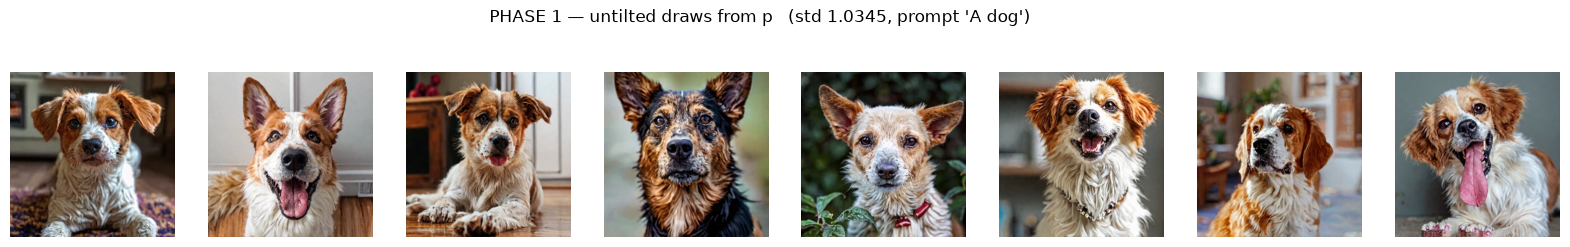


PHASE 1 GATE PASSED
STOP_AFTER=health -- stopping here.


In [4]:
from creativity_measure import LpDistance, Reward, flowmap_smc_sample

# --- PHASE 1 GATE: is p itself healthy? ------------------------------------------------------------
# If p looks degraded, stop before building 3 h on top of it.

S_ROW = 0.251            # s per denoiser row, measured on an A6000 (job 695266), +-2.5%
S_BASE_FLUX = 1.0150     # latent std of base FLUX.1-dev at this resolution (job 695271)


def _dummy_reward(n: int = 2) -> Reward:
    """A reward that costs nothing, for drawing from p itself.

    `flowmap_smc_sample` needs a `Reward` to pin d/device/dtype, but at lam = 0 its *value* cannot
    affect the trajectory (V = 0 everywhere, and systematic resampling on uniform weights is the
    identity). An L2 reward against dummy references is pure tensor arithmetic -- no network. Paired
    with `guid_window=(1.0, 1.0)` this skips every lookahead, so an untilted draw costs exactly one
    flow-map row per particle per step and NOT the M(2K+2) a guided step would.
    """
    return Reward(distance=LpDistance(p=2.0),
                  x_refs=torch.zeros(n, LATENT_DIM, device=DEVICE, dtype=torch.float32))


def draw_from_p(n: int, seed: int, *, verbose: bool = False) -> torch.Tensor:
    """n untilted samples from p, through the SAME stepping code path the tilted run uses.

    This is what makes the references valid: they are drawn by the base process the run will sample,
    not by some other integrator.
    """
    res = flowmap_smc_sample(_dummy_reward(), 0.0, n, **BASE_KW,
                             guid_window=(1.0, 1.0), mc_samples=1, seed=seed, verbose=verbose)
    return res.X.detach()


t0 = time.time()
health = draw_from_p(8, seed=1, verbose=True)
S_health = float(health.std())
print(f"\nuntilted draw: {tuple(health.shape)} in {time.time() - t0:.0f}s   "
      f"latent std = {S_health:.4f}  (base FLUX: {S_BASE_FLUX:.4f})")
print(f"  implied {(time.time() - t0) / (8 * N_STEPS):.3f} s/row vs {S_ROW} measured")

# --- gate 1: p is not degraded --------------------------------------------------------------------
assert 0.6 * S_BASE_FLUX < S_health < 1.6 * S_BASE_FLUX, (
    f"latent std {S_health:.4f} is far from base FLUX's {S_BASE_FLUX:.4f}: p looks degraded, and the "
    f"reward/lambda calibration built on top of it would be meaningless. Check the flow-map load, the "
    f"time-convention flip in FluxFlowMap._velocity, and GUIDANCE."
)

# --- gate 2: denoise(x, t) and map(x, t, 1) are genuinely different -------------------------------
# If they coincide, the two-timestep conditioning is inert and the load is suspect. denoise is a
# conditional mean, so it must be BLURRIER (lower variance) than the ODE endpoint, which is a sample.
t_probe = 0.5
gen = torch.Generator(device=DEVICE).manual_seed(0)
eps = torch.randn(health.shape, generator=gen, device=DEVICE, dtype=health.dtype)
x_t = SCHEDULE.alpha(t_probe) * health + SCHEDULE.sigma(t_probe) * eps
mean_est = flow_map.denoise(x_t, t_probe)
sample_est = flow_map.map(x_t, t_probe, 1.0)
rel_gap = float((mean_est - sample_est).norm() / sample_est.norm())
print(f"\nat t={t_probe}:  denoise std {float(mean_est.std()):.4f}   map(.,t,1) std "
      f"{float(sample_est.std()):.4f}   relative gap {rel_gap:.3f}")
assert rel_gap > 1e-3, (
    "denoise(x, t) == map(x, t, 1): the two-timestep conditioning is inert. Either the DualTimeEmbedder "
    "is not receiving a timestep pair, or the LoRA load was a no-op."
)
assert float(mean_est.std()) < float(sample_est.std()), (
    "the Tweedie mean is not blurrier than the ODE endpoint -- denoise and map are likely swapped"
)
assert torch.allclose(flow_map.map(x_t, t_probe, t_probe), x_t), "X_{t,t} must be the identity"

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, img in zip(axes, decode(health)):
    ax.imshow(img.permute(1, 2, 0).numpy()); ax.axis("off")
fig.suptitle(f"PHASE 1 — untilted draws from p   (std {S_health:.4f}, prompt {PROMPT!r})")
plt.savefig(os.path.join(RUN_DIR, f"phase1_health_{RUN_TAG}.png"), dpi=90, bbox_inches="tight")
plt.show()
print("\nPHASE 1 GATE PASSED")
if STOP_AFTER == "health":
    print("STOP_AFTER=health -- stopping here.")

In [5]:
from creativity_measure import SquaredGlobalIEMDistance
from creativity_measure.tilt import NormalizedExpectedDistanceReward

# --- PHASE 3: the frozen reward --------------------------------------------------------------------
# These constants DEFINE f, so changing any of them changes the target. Seeds are load-bearing:
# distance seed 123, reference seed 7 (both carried over from the validated run 695271).
R, N_GAMMA, NUM_EPS = 64, 30, 3
REF_SEED, DIST_SEED, HELDOUT_SEED = 7, 123, 8
N_HELDOUT = 32

REFS_PATH = os.path.join(RUN_DIR, f"refs_R{R}_seed{REF_SEED}.pt")
LAMS_PATH = os.path.join(RUN_DIR, f"lam_s_R{R}_seed{REF_SEED}.json")


def _assert_same_p(saved: dict) -> None:
    """The reference file is keyed to the base process -- but NOT to `guid_window`.

    References must be generated by the same stepping the run uses, so a mismatch means f describes a
    different p than the one being sampled. `guid_window` is deliberately absent: it may vary freely
    across runs sharing one reference set, which is what makes a window sweep a fair comparison.
    """
    keyed = ("schedule", "n_steps", "ts", "stoch_window", "inside_step", "outside_step",
             "img_shape", "model_id", "prompt", "guidance", "max_denoiser_rows")
    for k in keyed:
        got, want = saved["base_process"].get(k), BASE_PROCESS[k]
        if isinstance(want, tuple):
            got = tuple(got) if got is not None else got
        assert got == want, f"reference file was built under {k}={got!r}, this run uses {want!r}"
    assert "guid_window" not in saved["base_process"], "guid_window must not be keyed into p"


if DO_REFS:
    if os.path.exists(REFS_PATH):
        saved = torch.load(REFS_PATH, map_location="cpu", weights_only=False)
        _assert_same_p(saved)
        latent_refs = saved["x_refs"].to(DEVICE)
        heldout = saved["heldout"].to(DEVICE)
        print(f"references LOADED from {os.path.basename(REFS_PATH)} "
              f"(built on {saved.get('gpu', '?')}) -- the model is out of the reproducibility chain")
    else:
        # WHY THIS IS PERSISTED. Job 697271 aborted because references regenerated on a different GPU
        # shifted f by 16% of std_p(f) -- enough to change weight ratios by 1.25x. Saving the LATENTS
        # takes the model out of the chain, so every future leg gets a bit-identical reference set.
        t0 = time.time()
        latent_refs = draw_from_p(R, seed=REF_SEED)
        heldout = draw_from_p(N_HELDOUT, seed=HELDOUT_SEED)
        torch.save({"x_refs": latent_refs.detach().cpu(), "heldout": heldout.detach().cpu(),
                    "R": R, "seed": REF_SEED, "heldout_seed": HELDOUT_SEED,
                    "latent_dim": LATENT_DIM, "base_process": BASE_PROCESS,
                    "gpu": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu"},
                   REFS_PATH)
        print(f"references GENERATED in {(time.time() - t0) / 60:.1f} min and saved to "
              f"{os.path.basename(REFS_PATH)} -- future legs will load these")

    S = latent_refs.std().item()
    GAMMA_LO = max(1.0 / S**2, 1.0 / SIGMA_MAX**2)
    GAMMA_HI = min(2.0**10, 1.0 / SIGMA_MIN**2)
    GAMMAS = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2).to(DEVICE)

    D2 = SquaredGlobalIEMDistance(None, GAMMAS, num_eps=NUM_EPS, seed=DIST_SEED, score_fn=score_fn)
    t0 = time.time()
    reward = NormalizedExpectedDistanceReward(distance=D2, x_refs=latent_refs)   # builds the ref bank
    t_bank = time.time() - t0
    print(f"refs {tuple(latent_refs.shape)}  S={S:.4f}  gamma=[{GAMMA_LO:.4g}, {GAMMA_HI:.3g}] "
          f"x {N_GAMMA}   ref bank {t_bank / 60:.1f} min")

    # --- lambda_s: measured once, then CACHED --------------------------------------------------------
    # The two checks below cost (N_GAMMA-1)*NUM_EPS*(R + N_HELDOUT) = 8352 rows ~ 35 min. They are a
    # property of the (frozen) reward, so the run job loads the cached scalars instead of paying again.
    # `_assert_same_p` on the cache is what stops a stale lambda_s from silently calibrating a
    # different p. Delete lam_s_*.json to force a re-measure.
    cached = None
    if os.path.exists(LAMS_PATH):
        with open(LAMS_PATH) as fh:
            cached = json.load(fh)
        _assert_same_p(cached)
        assert cached["R"] == R and cached["n_gamma"] == N_GAMMA and cached["num_eps"] == NUM_EPS
        assert cached["dist_seed"] == DIST_SEED

    if cached is not None:
        lam_s = cached["lam_s"]
        F_P_MEAN, F_P_STD = cached["f_heldout_mean"], cached["f_heldout_std"]
        print(f"\nlambda_s LOADED from {os.path.basename(LAMS_PATH)}: {lam_s:.3f}  "
              f"(E_p[f] = {F_P_MEAN:.4f} +- {F_P_STD:.4f}, f(refs) = {cached['f_refs_mean']:.4f})")
    else:
        # --- reward sanity: f on its OWN references centres near (R-1)/R, not 1 ---------------------
        # The numerator averages over all R refs INCLUDING the self-pair zero; the denominator is the
        # off-diagonal pair mean, which drops it. A value near 1.0 would mean the self-pair is being
        # excluded somewhere, i.e. f is not the function the calibration assumes.
        t0 = time.time()
        f_refs = reward(latent_refs)
        print(f"\nf(refs): mean {float(f_refs.mean()):.4f}  (expected ~(R-1)/R = {(R - 1) / R:.4f})   "
              f"std {float(f_refs.std()):.4f}   [{(time.time() - t0) / 60:.1f} min]")
        assert abs(float(f_refs.mean()) - (R - 1) / R) < 0.10, \
            "f on its own refs is off the expected centre"

        # --- lambda_s on a HELD-OUT batch, never on the references themselves -----------------------
        t0 = time.time()
        f_heldout = reward(heldout)
        F_P_MEAN, F_P_STD = float(f_heldout.mean()), float(f_heldout.std())
        lam_s = 1.0 / F_P_STD
        print(f"held-out f: mean {F_P_MEAN:.4f}  std {F_P_STD:.4f}  "
              f"({N_HELDOUT} samples, {(time.time() - t0) / 60:.1f} min)")
        print(f"lambda_s = 1/std_p(f) = {lam_s:.3f}")
        with open(LAMS_PATH, "w") as fh:
            json.dump({"lam_s": lam_s, "f_heldout_mean": F_P_MEAN, "f_heldout_std": F_P_STD,
                       "f_refs_mean": float(f_refs.mean()), "S": S,
                       "R": R, "n_gamma": N_GAMMA, "num_eps": NUM_EPS,
                       "dist_seed": DIST_SEED, "base_process": BASE_PROCESS}, fh, indent=2,
                      default=str)
        print(f"saved -> {os.path.basename(LAMS_PATH)}")
if STOP_AFTER == "refs":
    print("\nSTOP_AFTER=refs -- stopping here.")

In [6]:
# --- PHASE 4: the tilted run ------------------------------------------------------------------------
M = 8                                        # particles
K = 4                                        # lookahead draws per particle per guided step
ETA = 1.5                                    # SNR factor: g(t') = eta*g(t)
ESS_THRESHOLD = 1.0                          # resample every step
GUID_WINDOW = (0.1, 1.0)                     # WHERE THE REWARD RUNS -- set empirically; see Takeaways
M_LIST = [float(x) for x in os.environ.get("M_LIST", "1,2,3").split(",")]
SEED = 101


class DeadlineReached(RuntimeError):
    """Raised from the `on_step` callback when the wall clock runs out, to stop the SMC cleanly."""


def make_checkpointer(path: str, config: dict):
    """Persist the cloud after every step, and stop the run at the deadline.

    The SMC is one long library call, so `on_step` is the only place a notebook can interrupt it.
    The callback is read-only and consumes no randomness, so the run is bit-identical to one without.
    Writes are temp-file + os.replace, so a kill mid-write cannot corrupt the last good file.
    """
    def on_step(i, snap, partial):
        payload = {
            "step": i, "t": snap.t,
            "X": snap.X, "U": snap.U, "V": snap.V, "ancestors": snap.ancestors,
            "ess_history": partial.ess_history, "resampled_history": partial.resampled_history,
            "uniq_history": partial.uniq_history, "t_history": partial.t_history,
            "t_prime_history": partial.t_prime_history, "guided_history": partial.guided_history,
            "f_mean": partial.f_mean, "f_std": partial.f_std,
            "f_min": partial.f_min, "f_max": partial.f_max,
            "l_mean": partial.l_mean, "l_std": partial.l_std,
            "s_mean": partial.s_mean, "s_std": partial.s_std,
            "config": config, "partial": True,
        }
        tmp = f"{path}.tmp"
        torch.save(payload, tmp)
        os.replace(tmp, path)
        elapsed = (time.time() - config["t0"]) / 60
        print(f"    [ckpt] step {i + 1}/{N_STEPS} t={snap.t:.4f}  {elapsed:.1f} min elapsed", flush=True)
        if time.time() > DEADLINE:
            raise DeadlineReached(f"deadline after step {i + 1} (t={snap.t:.4f})")
    return on_step


# --- cost projection ---------------------------------------------------------------------------
# One reward call on B latents costs (N_GAMMA-1)*NUM_EPS*B denoiser rows. At B = M*K = 32 that is the
# whole run: the reward is ~97% of a step, against M(2K+2) flow-map rows for the network itself.
if DO_RUN:
    _ts = [n / N_STEPS for n in range(N_STEPS + 1)]
    _guided = [n for n in range(N_STEPS - 1) if GUID_WINDOW[0] <= _ts[n + 1] <= GUID_WINDOW[1]]
    rew_rows = (N_GAMMA - 1) * NUM_EPS * M * K
    net_rows = M * (2 * K + 2)
    t_guided = (rew_rows + net_rows) * S_ROW
    t_terminal = ((N_GAMMA - 1) * NUM_EPS * M + M) * S_ROW
    t_unguided = M * S_ROW
    t_run = len(_guided) * t_guided + t_terminal + (N_STEPS - 1 - len(_guided)) * t_unguided
    budget_s = DEADLINE - time.time()
    print(f"projected per tilted run: {len(_guided)} guided steps x {t_guided / 60:.1f} min "
          f"+ terminal {t_terminal / 60:.1f} min  =  {t_run / 3600:.2f} h")
    print(f"  reward is {rew_rows / (rew_rows + net_rows):.1%} of a guided step "
          f"({rew_rows} reward rows vs {net_rows} flow-map rows at {S_ROW} s/row)")
    print(f"budget left {budget_s / 3600:.2f} h -> {budget_s / t_run:.1f} of the "
          f"{len(M_LIST)} requested m values ({M_LIST})")

results, run_paths = {}, {}
if DO_RUN:
    for m_tilt in M_LIST:
        lam = m_tilt * lam_s
        tag = f"N{M}_K{K}_m{m_tilt:g}_seed{SEED}_{RUN_TAG}"
        path = os.path.join(RUN_DIR, f"partial_{tag}.pt")
        config = {
            "M": M, "K": K, "eta": ETA, "n_steps": N_STEPS, "lam": lam, "m_tilt": m_tilt,
            "lam_s": lam_s, "seed": SEED, "ess_threshold": ESS_THRESHOLD,
            "guid_window": GUID_WINDOW, "base_process": BASE_PROCESS,
            "R": R, "n_gamma": N_GAMMA, "num_eps": NUM_EPS, "dist_seed": DIST_SEED,
            "refs_file": os.path.basename(REFS_PATH), "t0": time.time(),
        }
        if time.time() + t_run > DEADLINE:
            print(f"\nskipping m={m_tilt:g}: {t_run / 3600:.2f} h projected does not fit in the "
                  f"{(DEADLINE - time.time()) / 3600:.2f} h left")
            break
        print(f"\n=== m={m_tilt:g}  lambda={lam:.2f}  (lambda_s={lam_s:.2f})  "
              f"M={M} K={K} N={N_STEPS} eta={ETA} guid_window={GUID_WINDOW} ===", flush=True)
        t0, timed_out = time.time(), False
        try:
            res = flowmap_smc_sample(
                reward, lam, M, **BASE_KW, mc_samples=K, eta=ETA, guid_window=GUID_WINDOW,
                ess_threshold=ESS_THRESHOLD, antithetic=True, keep_steps=True,
                on_step=make_checkpointer(path, config), seed=SEED, verbose=True,
            )
        except DeadlineReached as exc:
            timed_out = True
            print(f"*** STOPPED ON DEADLINE: {exc}")
            res = None
        mins = (time.time() - t0) / 60
        if res is not None:
            final = os.path.join(RUN_DIR, f"result_{tag}.pt")
            torch.save({"X": res.X.cpu(), "logw": res.logw.cpu(),
                        "steps": [{"t": s.t, "X": s.X, "U": s.U, "V": s.V,
                                   "ancestors": s.ancestors} for s in (res.steps or [])],
                        "ess_history": res.ess_history, "resampled_history": res.resampled_history,
                        "uniq_history": res.uniq_history, "t_history": res.t_history,
                        "t_prime_history": res.t_prime_history, "guided_history": res.guided_history,
                        "f_mean": res.f_mean, "f_std": res.f_std, "f_min": res.f_min,
                        "f_max": res.f_max, "l_mean": res.l_mean, "l_std": res.l_std,
                        "s_mean": res.s_mean, "s_std": res.s_std,
                        "config": {**config, "wall_clock_min": mins}, "partial": False}, final)
            results[m_tilt], run_paths[m_tilt] = res, final
            print(f"m={m_tilt:g} completed in {mins:.1f} min ({mins / 60:.2f} h)  "
                  f"vs projected {t_run / 3600:.2f} h   saved -> {os.path.basename(final)}")
        else:
            print(f"m={m_tilt:g} incomplete after {mins:.1f} min; partial state in "
                  f"{os.path.basename(path)}")
            break

In [7]:
# --- PHASE 5: diagnostics ----------------------------------------------------------------------------
# Per CLAUDE.md, select the largest lambda whose uniq/N and min ESS/N stay above ~0.5.
# E_q[f] rises forever and is NOT the stopping signal -- degeneracy is.
if results:
    rows = []
    for m_tilt, res in sorted(results.items()):
        f_final = reward(res.X)
        w = torch.softmax(res.logw, dim=0)
        rows.append({
            "m": m_tilt, "lam": m_tilt * lam_s,
            "E_q[f]": float((w * f_final).sum()), "f_min": float(f_final.min()),
            "f_max": float(f_final.max()),
            "min ESS/M": min(res.ess_history) / M, "final ESS/M": res.ess_history[-1] / M,
            "uniq/M (final)": res.uniq_history[-1],
            "min uniq/M": min(res.uniq_history),
        })
    print(f"{'m':>4} {'lambda':>8} {'E_q[f]':>8} {'f_min':>7} {'f_max':>7} "
          f"{'minESS/M':>9} {'ESS/M':>7} {'uniq/M':>7} {'minuniq':>8}   verdict")
    for r in rows:
        ok = r["min ESS/M"] > 0.5 and r["uniq/M (final)"] > 0.5
        print(f"{r['m']:4.0f} {r['lam']:8.2f} {r['E_q[f]']:8.4f} {r['f_min']:7.4f} {r['f_max']:7.4f} "
              f"{r['min ESS/M']:9.2f} {r['final ESS/M']:7.2f} {r['uniq/M (final)']:7.2f} "
              f"{r['min uniq/M']:8.2f}   {'OK' if ok else 'DEGENERATE'}")
    print(f"\nreference point: E_p[f] on the held-out batch = {F_P_MEAN:.4f} +- {F_P_STD:.4f}")
    print(f"pCN ladder (jobs 695271+697271, ~14 h): reached m_eff = 1.63 of 3")

    # --- per-step diagnostics ------------------------------------------------------------------------
    n_m = len(results)
    fig, axes = plt.subplots(3, n_m, figsize=(5.5 * n_m, 11), squeeze=False)
    for j, (m_tilt, res) in enumerate(sorted(results.items())):
        t = res.t_history
        axes[0][j].plot(t, [e / M for e in res.ess_history], "o-", label="ESS/M")
        axes[0][j].plot(t, res.uniq_history, "s-", label="uniq/M")
        axes[0][j].axhline(0.5, color="r", ls=":", label="degeneracy floor")
        axes[0][j].set_title(f"m={m_tilt:g}  lambda={m_tilt * lam_s:.1f}")
        axes[0][j].set_ylim(0, 1.05); axes[0][j].legend(fontsize=8); axes[0][j].set_xlabel("t")

        axes[1][j].errorbar(t, res.f_mean, yerr=res.f_std, fmt="o-", capsize=2, label="f (lookahead)")
        axes[1][j].axhline(F_P_MEAN, color="k", ls="--", label="E_p[f]")
        axes[1][j].set_ylabel("reward"); axes[1][j].legend(fontsize=8); axes[1][j].set_xlabel("t")

        # The twist terms: at K=4 it is a live question whether L-hat / S-hat move the weights at all.
        axes[2][j].plot(t, res.l_mean, "o-", label="L (log-lik)")
        axes[2][j].plot(t, res.s_mean, "s-", label="S (score corr.)")
        axes[2][j].set_yscale("symlog"); axes[2][j].legend(fontsize=8)
        axes[2][j].set_xlabel("t"); axes[2][j].set_ylabel("raw term (mean)")
    fig.suptitle(f"Algorithm 3 diagnostics — M={M} K={K} N={N_STEPS} eta={ETA} "
                 f"guid_window={GUID_WINDOW}")
    fig.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, f"diagnostics_{RUN_TAG}.png"), dpi=110, bbox_inches="tight")
    plt.show()

    # --- decoded grid: one row per m, plus the untilted baseline -------------------------------------
    grid_rows = [("untilted (p)", health)] + [
        (f"m={m_tilt:g}  lam={m_tilt * lam_s:.0f}", res.X) for m_tilt, res in sorted(results.items())
    ]
    fig, axes = plt.subplots(len(grid_rows), M, figsize=(2.2 * M, 2.4 * len(grid_rows)),
                             squeeze=False)
    for i, (label, X) in enumerate(grid_rows):
        imgs = decode(X[:M])
        for j in range(M):
            axes[i][j].imshow(imgs[j].permute(1, 2, 0).numpy()); axes[i][j].axis("off")
        axes[i][0].set_ylabel(label, fontsize=9)
        axes[i][0].axis("on"); axes[i][0].set_xticks([]); axes[i][0].set_yticks([])
    fig.suptitle(f"Algorithm 3 on FLUX.1-dev flow map — {PROMPT!r}, guidance {GUIDANCE}")
    fig.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, f"tilt_grid_{RUN_TAG}.png"), dpi=110, bbox_inches="tight")
    plt.show()
else:
    print("no completed tilted runs to render "
          f"(STOP_AFTER={STOP_AFTER!r}); phase-1 images and any partial checkpoints are on disk.")
print(f"\ntotal wall clock: {(time.time() - T_START) / 3600:.2f} h")

no completed tilted runs to render (STOP_AFTER='health'); phase-1 images and any partial checkpoints are on disk.

total wall clock: 0.42 h


## Takeaways

*(Fill in after the run — this cell is the authoritative statement of what was learned, per repo convention.)*

**The comparison that matters.** Does one ~3 h forward pass reach a tilt strength the pCN ladder could not
reach in 14 h? The pCN reference point is jobs 695271 + 697271: $\beta = 0.5422$, i.e. $m_{\text{eff}} = 1.63$
of a targeted 3, with acceptance collapsing 0.75 → 0.12. Algorithm 3 targets $m \in \{1, 2, 3\}$ directly
with no acceptance rate to collapse.

**Read in this order:**

1. **`min ESS/M` and `uniq/M`** — the degeneracy signals. Per CLAUDE.md, select the largest $\lambda$ whose
   both stay above ~0.5. $E_q[f]$ rises forever and is *not* the stopping signal.
2. **`uniq_history[-1]`** specifically — if it is low, the returned images are near-duplicates. The real
   levers are `ess_threshold` (resample less often near the end) and `M`, **not** `stoch_window`: on the
   $N{=}16$ grid the last two steps inject only 0.055 and exactly 0, so a stochastic tail separates
   duplicates by ~0.08 per component on unit-scale latents and the final step is deterministic regardless.
3. **`l_mean` / `s_mean`** — whether the $\hat L$ / $\hat S$ terms move the weights at all at $K = 4$. This
   was left deliberately open by the plan. If they are negligible, `use_full_normalized_v=True` buys
   nothing and branch 1 ($\hat v_k = \lambda R_k$) is the right default it already is.
4. **`guid_window`** — the plan left the final value open, with $(0.1, 1.0)$ and $(0.9)$ both valid starting
   points. **Sweeping it needs no new references**: it is deliberately kept out of the base process, so
   every window shares one reference set and one $p$, which is what makes the comparison fair. A
   $(0.1, 0.9)$ window saves one guided step (~12 min) and lands its last lookahead update at $t = 0.875$;
   the terminal $V_N = \lambda f(x_1)$ still runs, which is what pins the target to $q_\lambda$.

**Open questions this run does not settle:** whether $M = 8$ is enough for `uniq/M` to be a usable
degeneracy signal at all, and whether the omitted fourth importance-weight term
($\tfrac12\lVert\varepsilon_k\rVert^2$, documented in `flowmap_smc_sample`'s docstring) matters — that is an
ablation, not a fix.